# e-1: Hover Policy via Behavioral Cloning

## Why are we doing this?

PPO learns by trial and error: take an action, get a reward, push the policy toward higher-reward actions.
That only works if the policy ever sees a *positive* reward. Our drone crashes at step ~43, so every
episode is short and negative — PPO has nothing good to reinforce.

**Behavioral cloning (BC)** is supervised learning from an expert. Instead of rewards, we use the
hand-tuned cascaded PID already in this codebase as a teacher. We collect states the PID visits and
the actions it takes, then train a neural network to imitate it. Once the network can hover (even
imperfectly), PPO episodes are long enough to produce useful gradient signal.

## Setup

| | |
|---|---|
| Environment | `ZeroTargetEnv`, `control_level='setpoint'` |
| Expert action | hover at spawn: `pos_des=(0,0,1)`, `yaw_des=0` |
| Network | 2-layer MLP [64, 64] — identical to SB3's default `MlpPolicy` |
| Loss | MSE between predicted and expert action |

In `setpoint` mode the RL agent only decides *where to point the drone*. The on-board cascaded PID
handles the actual flying. Saying 'hover here' every step is the optimal policy for `ZeroTargetEnv`.
BC just teaches the network that fact quickly instead of making PPO discover it by random search.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

from drone_sim.rl.custom_envs import ZeroTargetEnv
from drone_sim.rl.networks import SplitExtractor, FLIGHT_DIM, TARGET_DIM
from drone_sim.control.controller import CascadedController
from drone_sim.sim import compute_loadout
from drone_sim.physics import gun as gun_module
from drone_sim.config import DRONE, CTRL, SIM

## Step 1 — Set up the PID expert

In the previous approach the expert action was a **constant** setpoint: the network learned
'always output hover setpoint regardless of state', and the on-board PID did all the real work.

Here we clone the PID at the **thrust level**: for any drone state, the PID tells us exactly
which per-rotor thrusts to apply. The network learns a genuine feedback mapping —
if the drone is tilted left, it learns to apply more thrust on the left rotors, not just repeat
a constant setpoint.

We also generate training data **without running the simulation**. States are sampled analytically
from a Gaussian distribution centred at the nominal hover point. This is fast (100k samples in
seconds), gives us full control over the coverage, and avoids the episode-length bottleneck.

The PID expert:
- Input: `state` dict (`pos`, `quat`, `vel`, `omega_body`) + hover setpoint
- Output: 4 rotor thrusts in Newtons, clipped to `[0, DRONE.max_thrust_per_rotor]`
- We normalise these to `[-1, 1]` to match the `control_level='thrust'` action space


In [12]:
# Instantiate PID with the same mass/inertia the env uses
weapon         = gun_module.make_gun('m249_saw')
total_mass, inertia = compute_loadout(weapon)
pid_template   = CascadedController(DRONE, CTRL, total_mass=total_mass, inertia=inertia)

hover_setpoint = {
    'pos_des': np.array(SIM.init_pos, dtype=float),
    'yaw_des': float(SIM.init_yaw),
}

# Euler (ZYX) → MuJoCo quaternion [w, x, y, z]
def euler_to_quat(roll, pitch, yaw):
    cr, sr = np.cos(roll/2),  np.sin(roll/2)
    cp, sp = np.cos(pitch/2), np.sin(pitch/2)
    cy, sy = np.cos(yaw/2),   np.sin(yaw/2)
    q = np.array([
        cr*cp*cy + sr*sp*sy,
        sr*cp*cy - cr*sp*sy,
        cr*sp*cy + sr*cp*sy,
        cr*cp*sy - sr*sp*cy,
    ])
    return q / np.linalg.norm(q)

# Verify: hover state → symmetric thrusts
hover_state = {
    'pos':        np.array(SIM.init_pos, dtype=float),
    'quat':       np.array([1., 0., 0., 0.]),
    'vel':        np.zeros(3),
    'omega_body': np.zeros(3),
}
pid_template.reset()
T_hover = pid_template.update(hover_state, hover_setpoint, SIM.timestep)
T_hover_norm = 2.0 * T_hover / DRONE.max_thrust_per_rotor - 1.0
print(f'Hover thrusts (N):       {T_hover}')
print(f'Hover thrusts normalised: {T_hover_norm}')
print(f'Expected (total_mass*g/4): {total_mass * DRONE.gravity / 4:.2f} N per rotor')


Hover thrusts (N):       [30.3129 30.3129 30.3129 30.3129]
Hover thrusts normalised: [-0.32638 -0.32638 -0.32638 -0.32638]
Expected (total_mass*g/4): 30.31 N per rotor


## Step 2 — Generate the dataset

We sample 100 000 drone states from a Gaussian distribution centred at the nominal hover.
The distribution widths are chosen to cover realistic flight perturbations:

| Variable | Distribution |
|---|---|
| position | N(init_pos, [0.5, 0.5, 0.2] m) |
| roll / pitch | N(0, 15°) — small perturbations |
| yaw | Uniform(-π, π) — any heading |
| linear velocity | N(0, [0.5, 0.5, 0.3] m/s) |
| angular velocity | N(0, [0.5, 0.5, 0.2] rad/s) |

For each state we call a fresh PID instance (integrator = 0, I-term negligible for a single step).
The PID returns 4 rotor thrusts; we normalise them to `[-1, 1]` and store `(obs, action)` pairs.

**Why fresh PID per sample?** The PID has an internal integrator. If we reuse the same instance
across unrelated states, the accumulated integral doesn't correspond to any real flight history
and would corrupt the labels. A fresh instance has zero integral, so the output is pure P+D,
which is what the controller relies on for transient corrections anyway.


In [ ]:
N_SAMPLES = 100_000
rng = np.random.default_rng(42)

obs_list, act_list = [], []

for _ in range(N_SAMPLES):
    # --- sample state ---
    pos   = np.array(SIM.init_pos) + rng.normal(0.0, [0.5, 0.5, 0.2])
    pos[2] = max(0.2, pos[2])               # keep above ground

    roll  = rng.normal(0.0, np.radians(15))
    pitch = rng.normal(0.0, np.radians(15))
    yaw   = rng.uniform(-np.pi, np.pi)
    quat  = euler_to_quat(roll, pitch, yaw)

    vel   = rng.normal(0.0, [0.5, 0.5, 0.3])
    omega = rng.normal(0.0, [0.5, 0.5, 0.2])

    state = {'pos': pos, 'quat': quat, 'vel': vel, 'omega_body': omega}

    # --- expert action: fresh PID (zero integrator) ---
    pid = CascadedController(DRONE, CTRL, total_mass=total_mass, inertia=inertia)
    thrust = pid.update(state, hover_setpoint, SIM.timestep)  # [T1..T4] in Newtons

    # Normalise to [-1,1]: inverse of env's decoding ((action+1)*0.5*max_thrust)
    action = 2.0 * thrust / DRONE.max_thrust_per_rotor - 1.0

    # Fire label = +1.0 (always fire).
    # -1.0 here drives the action_net fire output to -1 after BC training.
    # In SingleTargetEnv, sampling fire>0 then requires z=(0-(-1))/0.135=7.4
    # stddevs, probability ~10^-13. The policy aims perfectly but never fires.
    # Starting at +1 means ZeroTargetEnv PPO can decide whether firing hurts
    # stability, and SingleTargetEnv PPO starts with a firing policy to build on.
    action_full = np.append(action, 1.0).astype(np.float32)

    # --- obs: matches ZeroTargetEnv._get_obs() layout exactly ---
    # [pos(3), quat(4), vel(3), omega(3), ammo(1), target_rel(3)] = 17
    obs = np.concatenate([
        pos, quat, vel, omega,
        np.array([1.0]),   # ammo_norm = full
        np.zeros(3),       # target_rel = 0 (no targets)
    ]).astype(np.float32)

    obs_list.append(obs)
    act_list.append(action_full)

obs_arr = np.array(obs_list, dtype=np.float32)
act_arr = np.array(act_list, dtype=np.float32)
print(f'Generated {len(obs_arr):,} samples')
print(f'obs shape: {obs_arr.shape},  act shape: {act_arr.shape}')
print(f'Thrust action mean:  {act_arr[:, :4].mean(axis=0)}')
print(f'Thrust action std:   {act_arr[:, :4].std(axis=0)}')
print(f'Fire action mean:    {act_arr[:, 4].mean():.2f}  (should be 1.0)')

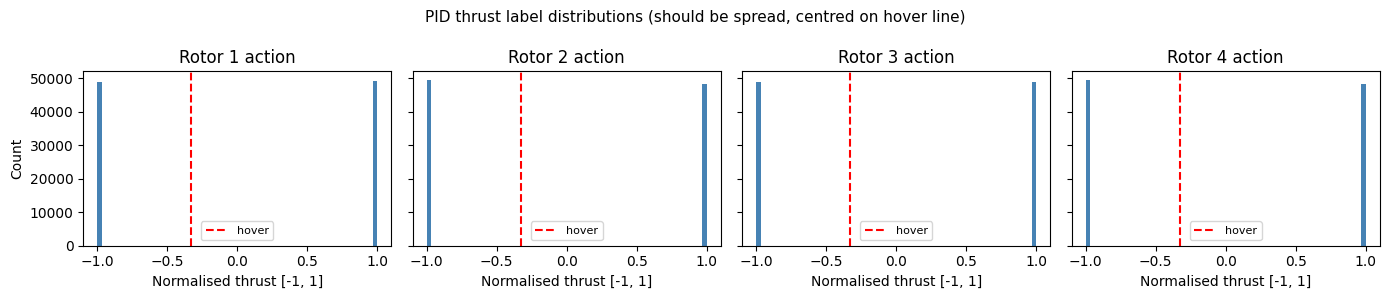

In [14]:
# The thrust labels should vary with state — not a constant.
# Mean should be near the hover thrust; spread reflects the range of corrections.
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for i, ax in enumerate(axes):
    ax.hist(act_arr[:, i], bins=60, color='steelblue', edgecolor='none')
    ax.axvline(T_hover_norm[i], color='red', linestyle='--', label='hover')
    ax.set_title(f'Rotor {i+1} action')
    ax.set_xlabel('Normalised thrust [-1, 1]')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Count')
plt.suptitle('PID thrust label distributions (should be spread, centred on hover line)', fontsize=11)
plt.tight_layout()
plt.savefig('bc_obs_dist.png', dpi=100)
plt.show()


## Step 3 — Define the policy network

We use a **split two-stream MLP**: a dedicated `flight_enc` for the 14 flight-state dims and a
separate `target_enc` for the 3 target-relative dims.

```
obs (17)
 ├─ flight_enc : obs[0:14]  →  Linear(14,64) → Tanh  →  64
 └─ target_enc : obs[14:17] →  Linear(3,16)  → Tanh  →  16
                                                          │ concat → 80
                              policy_net : Linear(80,64) → Tanh → Linear(64,64) → Tanh → 64
                              action_head: Linear(64,5) → action (5)
```

**Why split instead of a flat MLP?**

BC training data always has `target_rel = [0, 0, 0]`. In a flat first layer, gradient w.r.t. the
target-column weights is `input × upstream_grad = 0 × … = 0` — those weights receive no update and
stay at their random initialisation. That's fine, but a flat layer also mixes flight and target
streams through shared neurons, so later when PPO tries to grow the target weights from their
random init in SingleTargetEnv, the gradients interfere with the already-trained flight path.

With the split, each stream is independent:
- `flight_enc` is fully trained by BC (hover behaviour locked in).
- `target_enc` weights are untouched by BC (input always zero → zero gradient to weights).
  PPO in SingleTargetEnv trains them freely without disturbing the hover path.

This also scales cleanly to the end goal: add a `gun_enc` for weapon state, a `threat_enc` for
adversaries, pool over multiple targets — just concatenate more streams before `policy_net`.

**Architecture matches SB3's layout exactly** (`SplitExtractor` features extractor with
`features_dim=80` + `net_arch=[64, 64]`), enabling direct weight transfer.

In [15]:
FLIGHT_DIM = 14   # pos(3) + quat(4) + vel(3) + omega_body(3) + ammo(1)
TARGET_DIM = 3    # target_rel(3)
ACT_DIM    = act_arr.shape[1]   # 5

class SplitHoverPolicy(nn.Module):
    """
    Two-stream MLP that mirrors SB3's SplitExtractor + net_arch=[64,64] layout.

    flight_enc  : obs[0:14]  → Linear(14,64) → Tanh → 64
    target_enc  : obs[14:17] → Linear(3,16)  → Tanh → 16  (weights stay ~random during BC)
    policy_net  : concat(80) → Linear(80,64) → Tanh → Linear(64,64) → Tanh → 64
    action_head : Linear(64,5)
    """
    def __init__(self, flight_dim=FLIGHT_DIM, target_dim=TARGET_DIM,
                 act_dim=ACT_DIM, hidden=64):
        super().__init__()
        self.flight_enc = nn.Sequential(nn.Linear(flight_dim, hidden), nn.Tanh())
        self.target_enc = nn.Sequential(nn.Linear(target_dim, hidden // 4), nn.Tanh())
        self.policy_net = nn.Sequential(
            nn.Linear(hidden + hidden // 4, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.action_head = nn.Linear(hidden, act_dim)

    def forward(self, x):
        f = self.flight_enc(x[:, :FLIGHT_DIM])
        t = self.target_enc(x[:, FLIGHT_DIM:])
        return self.action_head(self.policy_net(torch.cat([f, t], dim=1)))

policy = SplitHoverPolicy()
print(policy)
print(f'\nTotal parameters: {sum(p.numel() for p in policy.parameters()):,}')

SplitHoverPolicy(
  (flight_enc): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): Tanh()
  )
  (target_enc): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): Tanh()
  )
  (policy_net): Sequential(
    (0): Linear(in_features=80, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
  )
  (action_head): Linear(in_features=64, out_features=5, bias=True)
)

Total parameters: 10,693


## Step 4 — Train with MSE loss

Standard supervised learning: input = observation, label = expert action, loss = MSE.
The network has no knowledge of physics — it just learns the input→output mapping from data.

Because the expert action is always the same constant `hover_action`, the network is learning
'output ~[0, 0, -0.8, 0, -1] regardless of what the observation is'. That sounds trivial, but
a randomly initialised PPO policy outputs something completely different, which is why it crashes immediately.

In [16]:
EPOCHS     = 60
BATCH_SIZE = 512
LR         = 3e-4

dataset = TensorDataset(torch.tensor(obs_arr), torch.tensor(act_arr))
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

optimizer   = torch.optim.Adam(policy.parameters(), lr=LR)
loss_fn     = nn.MSELoss()
train_losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for obs_batch, act_batch in loader:
        pred = policy(obs_batch)
        loss = loss_fn(pred, act_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(obs_batch)
    train_losses.append(epoch_loss / len(dataset))
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}  loss = {train_losses[-1]:.6f}')

torch.save(policy.state_dict(), 'hover_policy_bc.pt')
print('\nSaved hover_policy_bc.pt')


Epoch  10/60  loss = 0.013953
Epoch  20/60  loss = 0.005693
Epoch  30/60  loss = 0.004662
Epoch  40/60  loss = 0.004393
Epoch  50/60  loss = 0.004082
Epoch  60/60  loss = 0.003558

Saved hover_policy_bc.pt


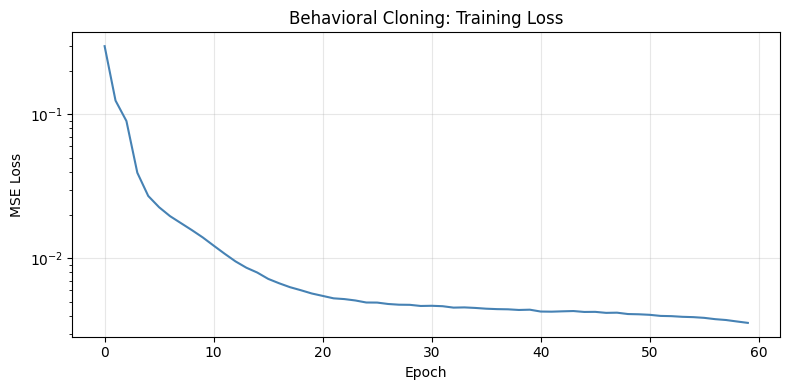

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Behavioral Cloning: Training Loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bc_loss.png', dpi=100)
plt.show()


## Step 5 — Evaluate in closed loop

We run the trained network closed-loop: network outputs action → env steps → next obs → network.
If the episode reaches the max step count the drone hovered successfully. Compare this against
the random baseline (step ~43) to see whether BC actually helped.

Episode length:   500 / 500  (random baseline: ~43)
Total reward:     401.82
Mean reward/step: 0.8036


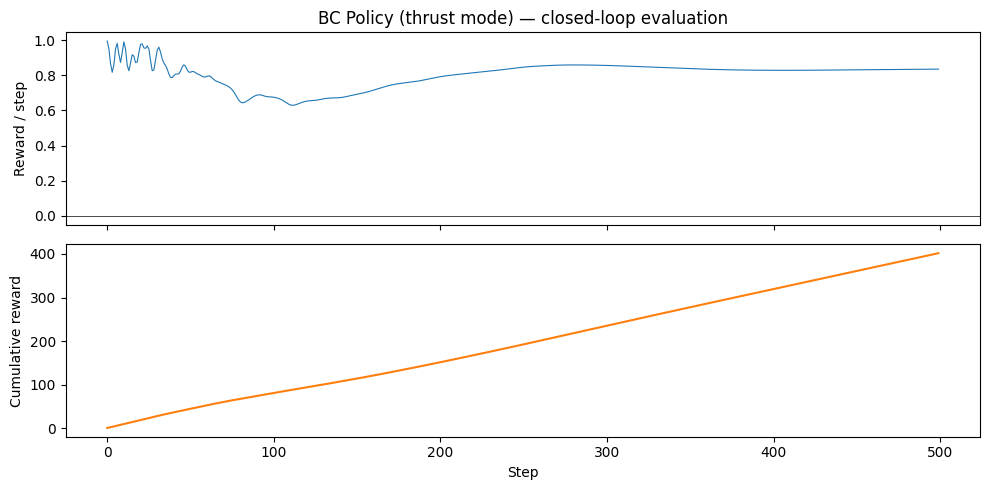

In [18]:
def run_bc_episode(model, n_steps=500, seed=99):
    env = ZeroTargetEnv(control_level='thrust', seed=seed)  # must match BC training
    obs, _ = env.reset(seed=seed)
    model.eval()
    rewards, ep_len = [], 0
    with torch.no_grad():
        for _ in range(n_steps):
            action = model(torch.tensor(obs).unsqueeze(0)).squeeze().numpy()
            action = np.clip(action, -1.0, 1.0)
            obs, r, terminated, truncated, _ = env.step(action)
            rewards.append(float(r))
            ep_len += 1
            if terminated or truncated:
                break
    env.close()
    return rewards, ep_len

rewards, length = run_bc_episode(policy)
print(f'Episode length:   {length} / 500  (random baseline: ~43)')
print(f'Total reward:     {sum(rewards):.2f}')
print(f'Mean reward/step: {np.mean(rewards):.4f}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax1.plot(rewards, linewidth=0.8)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_ylabel('Reward / step')
ax1.set_title('BC Policy (thrust mode) — closed-loop evaluation')
ax2.plot(np.cumsum(rewards), color='C1')
ax2.set_ylabel('Cumulative reward')
ax2.set_xlabel('Step')
plt.tight_layout()
plt.show()


## Step 6 — Transfer weights into SB3 PPO, then fine-tune

We copy the actor weights from `HoverPolicy` into a freshly created PPO model.
The **critic (value function) stays randomly initialised** — PPO will learn it from scratch,
which is fine because the critic is only used for advantage estimation during training.

**Why the architectures match**: SB3's `MlpPolicy` with `net_arch=[64, 64]` (the default) is:
- `mlp_extractor.policy_net` = `Sequential(Linear(18,64), Tanh, Linear(64,64), Tanh)`
  - Linear layers sit at indices **0** and **2** (Tanh layers sit at 1 and 3)
- `action_net` = `Linear(64, 5)`

Our `HoverPolicy.net` is the same structure, so we copy layer by layer.

In [ ]:
import gymnasium as gym

# SplitExtractor is imported from drone_sim.rl.networks — no inline definition needed.

vec_env = make_vec_env(lambda: ZeroTargetEnv(control_level='thrust'), n_envs=4)

ppo_model = PPO(
    'MlpPolicy', vec_env,
    learning_rate=1e-4,
    ent_coef=0.01,
    policy_kwargs={
        'features_extractor_class':  SplitExtractor,
        'features_extractor_kwargs': {'features_dim': 80},
        'net_arch': [64, 64],
        'log_std_init': -2.0,
    },
    verbose=1,
)

# --- Weight transfer ---
ext  = ppo_model.policy.features_extractor
pnet = ppo_model.policy.mlp_extractor.policy_net  # [Lin(80,64), Tanh, Lin(64,64), Tanh]

ext.flight_enc[0].weight.data.copy_(policy.flight_enc[0].weight.data)
ext.flight_enc[0].bias.data.copy_(  policy.flight_enc[0].bias.data)

ext.target_enc[0].weight.data.copy_(policy.target_enc[0].weight.data)
ext.target_enc[0].bias.data.copy_(  policy.target_enc[0].bias.data)

pnet[0].weight.data.copy_(policy.policy_net[0].weight.data)
pnet[0].bias.data.copy_(  policy.policy_net[0].bias.data)
pnet[2].weight.data.copy_(policy.policy_net[2].weight.data)
pnet[2].bias.data.copy_(  policy.policy_net[2].bias.data)

ppo_model.policy.action_net.weight.data.copy_(policy.action_head.weight.data)
ppo_model.policy.action_net.bias.data.copy_(  policy.action_head.bias.data)

print('Weights transferred.')
print('log_std:', ppo_model.policy.log_std.data)

# Sanity check: BC network and SB3 actor should agree exactly on hover obs
hover_obs = np.concatenate([
    SIM.init_pos, [1.,0.,0.,0.], np.zeros(3), np.zeros(3),
    [1.0], np.zeros(3)
]).astype(np.float32)
test_obs = torch.tensor(hover_obs).unsqueeze(0)
with torch.no_grad():
    dist     = ppo_model.policy.get_distribution(test_obs)
    ppo_mean = dist.distribution.loc.numpy().squeeze()
    bc_mean  = policy(test_obs).numpy().squeeze()
print(f'BC network output:    {bc_mean}')
print(f'SB3 actor mean:       {ppo_mean}')
print(f'Hover thrust norm:    {np.append(T_hover_norm, -1.)}')
print(f'Max mean difference:  {abs(ppo_mean - bc_mean).max():.6f}  (should be ~0)')

In [20]:
ppo_model.learn(total_timesteps=1_000_000, reset_num_timesteps=True)
ppo_model.save('ppo_e-1_bc_hover2')
print('Saved ppo_e-1_bc_hover.zip')


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 117      |
|    ep_rew_mean     | -218     |
| time/              |          |
|    fps             | 1840     |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 8192     |
---------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 123       |
|    ep_rew_mean          | -165      |
| time/                   |           |
|    fps                  | 1138      |
|    iterations           | 2         |
|    time_elapsed         | 14        |
|    total_timesteps      | 16384     |
| train/                  |           |
|    approx_kl            | 3.9609509 |
|    clip_fraction        | 0.8       |
|    clip_range           | 0.2       |
|    entropy_loss         | 2.87      |
|    explained_variance   | -0.00195  |
|    learning_rate        | 0.0001    |
|    loss           